In [21]:
import pandas as pd

# import cleaned data from first notebook
final_data2 = pd.read_csv("../data/final.csv")
final_data_trait = pd.read_csv("../data/final.csv")

print("Loaded final.csv with", final_data_trait.shape[0], "rows and", final_data_trait.shape[1], "columns")

Loaded final.csv with 1453 rows and 22 columns


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [24]:
# take log
final_data_trait["log_intrastate_deaths"] = np.log1p(
    final_data_trait["intrastate_deaths"]
)

In [25]:
# find correlations
correlations = final_data_trait[
    [
        "hierarchy",
        "exclusivity",
        "collectivism",
        "political_theology",
        "pluralism_tolerance",
        "log_intrastate_deaths"
    ]
].corr()["log_intrastate_deaths"].drop("log_intrastate_deaths")


correlations

hierarchy             -0.000560
exclusivity           -0.000560
collectivism           0.139680
political_theology     0.099889
pluralism_tolerance   -0.104902
Name: log_intrastate_deaths, dtype: float64

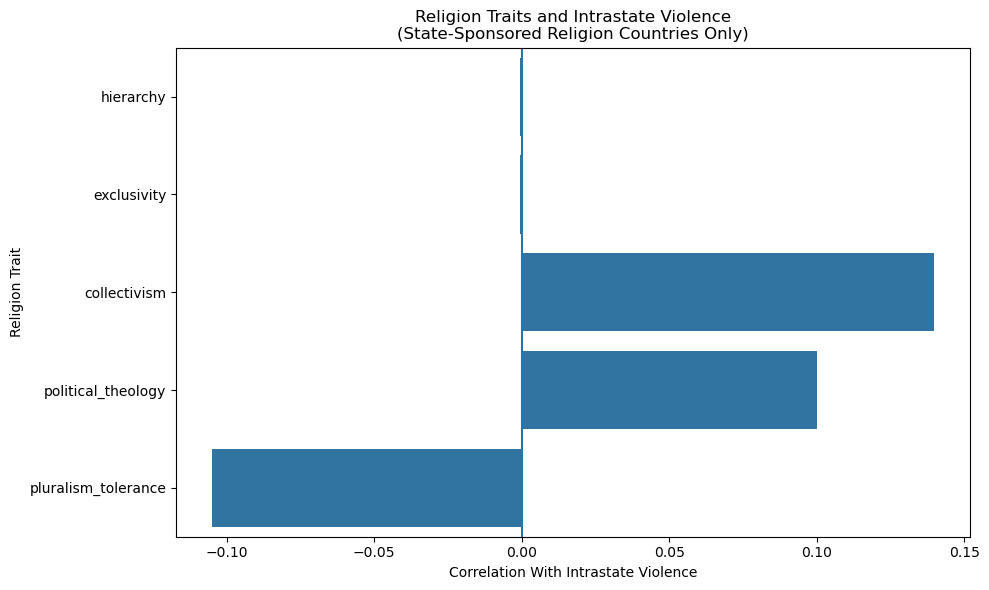

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = correlations.reset_index()
corr_df.columns = [
    "religion_trait",
    "correlation"
]

# create trait visualization

plt.figure(figsize=(10,6))

sns.barplot(
    data=corr_df,
    x="correlation",
    y="religion_trait"
)

plt.axvline(0)

plt.xlabel(
    "Correlation With Intrastate Violence"
)
plt.ylabel("Religion Trait")

plt.title(
    "Religion Traits and Intrastate Violence\n(State-Sponsored Religion Countries Only)"
)

plt.tight_layout()
plt.show()

In [27]:
# make sure there's enough in all categories
religion_counts = (
    final_data2
    .groupby(
        ["majority_religion",
         "state-sponsored religion index"]
    )
    .size()
)

print(religion_counts)

majority_religion         state-sponsored religion index
Buddhists                 0.0                                51
                          2.0                                 1
Christians                0.0                               391
                          2.0                                 3
Hindus                    0.0                                48
Jews                      2.0                                36
Muslims                   0.0                               305
                          2.0                               288
Religiously_Unaffiliated  0.0                                 8
dtype: int64


In [28]:
religion_conflict = (
    final_data2
    .groupby(
        ["majority_religion",
         "state-sponsored religion index"]
    )["intrastate_deaths"]
    .median()
    .reset_index()
)

In [29]:
# key info
print("Total observations:", final_data2.shape[0])
print("Unique countries:", final_data2["country"].nunique())
print("Year range:", final_data2["year"].min(), "-", final_data2["year"].max())
print("Countries with state religion:", (final_data2["state-sponsored religion index"] == 2).sum())
print("Countries without state religion:", (final_data2["state-sponsored religion index"] != 2).sum())
print("Missing state religion:", final_data2["state-sponsored religion index"].isna().sum())
print("Missing majority religion:", final_data2["majority_religion"].isna().sum())
print("Missing intrastate deaths:", final_data2["intrastate_deaths"].isna().sum())
print("\nObservations by region:")
print(final_data2["Region"].value_counts())
print("\nObservations by majority religion:")
print(final_data2["majority_religion"].value_counts())

Total observations: 1453
Unique countries: 106
Year range: 1989 - 2024
Countries with state religion: 328
Countries without state religion: 1125
Missing state religion: 322
Missing majority religion: 156
Missing intrastate deaths: 0

Observations by region:
Region
Sub-Saharan Africa          445
Asia-Pacific                424
Middle East-North Africa    256
Latin America-Caribbean     100
Europe                       72
Name: count, dtype: int64

Observations by majority religion:
majority_religion
Muslims                     678
Christians                  470
Buddhists                    55
Hindus                       48
Jews                         36
Religiously_Unaffiliated     10
Name: count, dtype: int64


In [30]:
final_data2.groupby(
    ["Region", "state-sponsored religion index"]
).size()

Region                    state-sponsored religion index
Asia-Pacific              0.0                               254
                          2.0                                98
Europe                    0.0                                52
                          2.0                                 1
Latin America-Caribbean   0.0                                94
                          2.0                                 2
Middle East-North Africa  0.0                                26
                          2.0                               212
Sub-Saharan Africa        0.0                               377
                          2.0                                15
dtype: int64

In [31]:
# omit europe, 
filtered_by_region = final_data2[
    ~final_data2["Region"].isin([
        "Europe",
        "North America"
    ])
]

final_data3 = (
    filtered_by_region
    .groupby(["Region", "state-sponsored religion index"])
    ["intrastate_deaths"]
    .median()
    .reset_index()
)

In [32]:
print(correlations)

hierarchy             -0.000560
exclusivity           -0.000560
collectivism           0.139680
political_theology     0.099889
pluralism_tolerance   -0.104902
Name: log_intrastate_deaths, dtype: float64


In [33]:
print(final_data3.to_string())

                     Region  state-sponsored religion index  intrastate_deaths
0              Asia-Pacific                             0.0               96.5
1              Asia-Pacific                             2.0              421.5
2   Latin America-Caribbean                             0.0              103.0
3   Latin America-Caribbean                             2.0               75.0
4  Middle East-North Africa                             0.0               76.5
5  Middle East-North Africa                             2.0              224.0
6        Sub-Saharan Africa                             0.0              141.0
7        Sub-Saharan Africa                             2.0               12.0


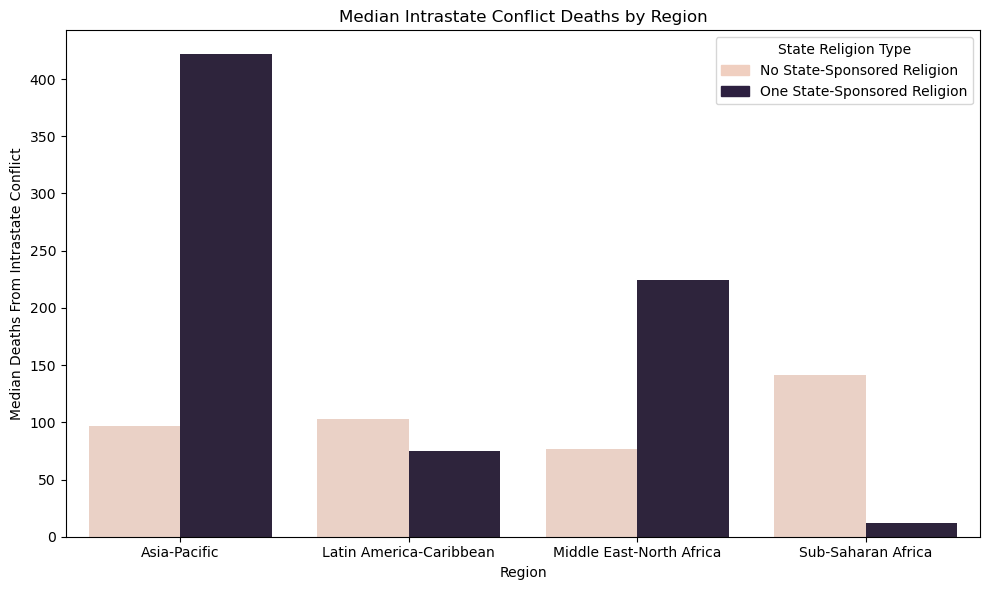

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=final_data3,
    x="Region",
    y="intrastate_deaths",
    hue="state-sponsored religion index",
    palette={0.0: "#f0cfc0", 2.0: "#2d2040"},
    ax=ax
)

# Fix legend with correct colored patches
no_religion_patch = mpatches.Patch(color="#f0cfc0", label="No State-Sponsored Religion")
one_religion_patch = mpatches.Patch(color="#2d2040", label="One State-Sponsored Religion")

ax.legend(
    handles=[no_religion_patch, one_religion_patch],
    title="State Religion Type",
    loc="upper right"
)

ax.set_xlabel("Region")
ax.set_ylabel("Median Deaths From Intrastate Conflict")
ax.set_title("Median Intrastate Conflict Deaths by Region")

plt.tight_layout()
plt.savefig("region.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
region_conflict = (
    final_data2
    .groupby(
        ["Region", "state-sponsored religion index"]
    )["intrastate_deaths"]
    .median()
    .reset_index()
)

In [36]:
final_data2.groupby(
    ["Region", "state-sponsored religion index"]
).size()

Region                    state-sponsored religion index
Asia-Pacific              0.0                               254
                          2.0                                98
Europe                    0.0                                52
                          2.0                                 1
Latin America-Caribbean   0.0                                94
                          2.0                                 2
Middle East-North Africa  0.0                                26
                          2.0                               212
Sub-Saharan Africa        0.0                               377
                          2.0                                15
dtype: int64

In [37]:
filtered_by_region = final_data2[
    ~final_data2["Region"].isin([
        "Europe",
        "Latin America-Caribbean"
    ])
]

final_data3 = (
    filtered_by_region
    .groupby(["Region", "state-sponsored religion index"])
    ["intrastate_deaths"]
    .median()
    .reset_index()
)

In [39]:
final_data_trait["log_intrastate_deaths"] = np.log1p(
    final_data_trait["intrastate_deaths"]
)

trait_cols = [
    "hierarchy",
    "exclusivity",
    "collectivism",
    "political_theology",
    "pluralism_tolerance"
]

trait_correlations = (
    final_data_trait[trait_cols + ["log_intrastate_deaths"]]
    .corr()["log_intrastate_deaths"]
    .drop("log_intrastate_deaths")
    .sort_values()
)

trait_correlations

pluralism_tolerance   -0.104902
hierarchy             -0.000560
exclusivity           -0.000560
political_theology     0.099889
collectivism           0.139680
Name: log_intrastate_deaths, dtype: float64

In [48]:
plt.savefig("../output/final_regions.png", dpi=150, bbox_inches="tight")

plt.savefig("../output/final_traits.png", dpi=150, bbox_inches = "tight")

<Figure size 640x480 with 0 Axes>